## Grover's Algorithm


In [6]:
NUM_QUBITS = 5

dev = qml.device("default.qubit", wires=NUM_QUBITS)


@qml.qnode(dev)
def circuit_default_qubit():
    return grover_circuit(NUM_QUBITS)


results = circuit_default_qubit()

In [7]:
def most_probable_states_descending(probs, N):
    """Returns the indices of the N most probable states in descending order."""
    if N > len(probs):
        raise ValueError("N cannot be greater than the length of the probs array.")

    return np.argsort(probs)[-N:][::-1]


def print_most_probable_states_descending(probs, N):
    """Prints the most probable states and their probabilities in descending order."""
    for i in most_probable_states_descending(probs, N):
        print(f"Prob of state '{i:0{NUM_QUBITS}b}': {probs[i]:.4g}")


print_most_probable_states_descending(results, N=2)

Prob of state '00000': 0.2909
Prob of state '11111': 0.2909


## JIT Compile of Grover's Algorithm

In [8]:
dev = qml.device("lightning.qubit", wires=NUM_QUBITS)


@qml.qnode(dev)
def circuit_lightning():
    return grover_circuit(NUM_QUBITS)

In [9]:
circuit_qjit = qml.qjit(circuit_lightning)

In [10]:
results_qjit = circuit_qjit()
print_most_probable_states_descending(results_qjit, N=2)

Prob of state '11111': 0.2909
Prob of state '00000': 0.2909


In [11]:
results_are_equal = np.allclose(results, results_qjit, atol=1e-12)
print(f"Native-Python and compiled circuits yield same results? {results_are_equal}")

Native-Python and compiled circuits yield same results? True


### Benchmark

In [12]:
import timeit

NUM_REPS = 5

runtimes_native_default = timeit.repeat(
    "circuit_default_qubit()",
    globals={"circuit_default_qubit": circuit_default_qubit},
    number=1,
    repeat=1,
)
runtimes_native_lightning = timeit.repeat(
    "circuit_lightning()",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=NUM_REPS,
)
runtimes_compilation = timeit.repeat(
    "qml.qjit(circuit_lightning)",
    setup="import pennylane as qml",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=1,
)
runtimes_qjit_call = timeit.repeat(
    "_circuit_qjit()",
    setup="import pennylane as qml; _circuit_qjit = qml.qjit(circuit_lightning);",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=NUM_REPS,
)

run_names = [
    "Native (default.qubit)",
    "Native (lightning.qubit)",
    "QJIT compilation",
    "QJIT call",
]
run_names_display = [name.replace(" ", "\n", 1) for name in run_names]
runtimes = [
    np.mean(runtimes_native_default),
    np.mean(runtimes_native_lightning),
    np.mean(runtimes_compilation),
    np.mean(runtimes_qjit_call),
]


def std_err(x):
    """Standard error = sample standard deviation / sqrt(sample size)"""
    if len(x) == 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


runtimes_err = [
    std_err(runtimes_native_default),
    std_err(runtimes_native_lightning),
    std_err(runtimes_compilation),
    std_err(runtimes_qjit_call),
]

for i in range(len(run_names)):
    print(f"{run_names[i]} runtime: ({runtimes[i]:.4g} +/- {runtimes_err[i]:.2g}) s")

Native (default.qubit) runtime: (0.003455 +/- nan) s
Native (lightning.qubit) runtime: (0.00154 +/- 0.00021) s
QJIT compilation runtime: (0.4344 +/- nan) s
QJIT call runtime: (0.01473 +/- 0.0012) s


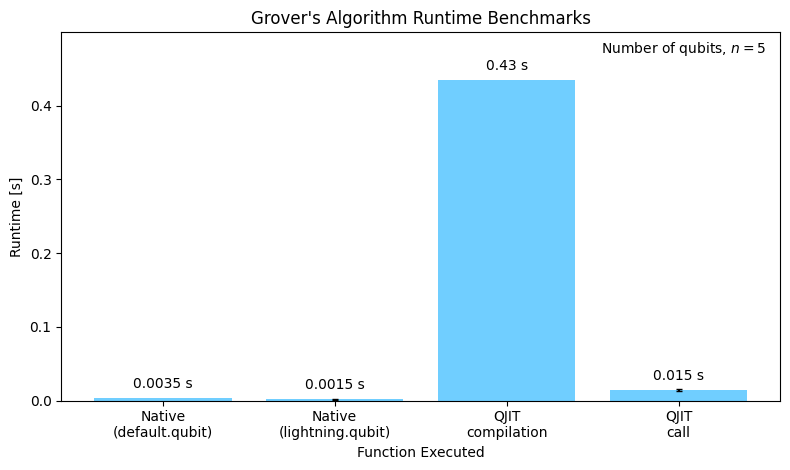

In [13]:
fig = plt.figure(figsize=[8.0, 4.8])
plt.title("Grover's Algorithm Runtime Benchmarks")
bars = plt.bar(run_names_display, runtimes, color="#70CEFF")
plt.errorbar(
    run_names_display, runtimes, yerr=runtimes_err, fmt="None", capsize=2.0, c="k"
)
plt.bar_label(bars, fmt="{:#.2g} s", padding=5)
plt.xlabel("Function Executed")
plt.ylabel("Runtime [s]")
plt.margins(y=0.15)
plt.text(
    0.98,
    0.98,
    f"Number of qubits, $n = {NUM_QUBITS}$",
    ha="right",
    va="top",
    transform=plt.gca().transAxes,
)
plt.tight_layout()
plt.show()

In [15]:

# Use the same wires and logic as your other circuits
dev_jax = qml.device("lightning.qubit", wires= NUM_QUBITS)

@qml.qnode(dev_jax, interface="jax")
def circuit_jax():
    # Call the same internal logic as circuit_lightning
    # or just copy the operations here
    return circuit_lightning() 


In [18]:

wires = NUM_QUBITS
# 1. Define the operations in a plain function (remove any @qml.qnode decorator)
def grover_logic():
    # ... put your quantum gates here ...
    # e.g.,
    # qml.Hadamard(wires=0)
    # qml.PauliZ(wires=0)
    return qml.expval(qml.PauliZ(0))

# 2. Create the different QNodes from the same logic
dev_lightning = qml.device("lightning.qubit", wires=wires)
dev_jax = qml.device("lightning.qubit", wires=wires)

circuit_lightning = qml.QNode(grover_logic, dev_lightning)
circuit_jax = qml.QNode(grover_logic, dev_jax, interface="jax")

# 3. Now the benchmarking will work correctly
runtimes_jax_native = timeit.repeat(
    "circuit_jax()",
    globals={"circuit_jax": circuit_jax},
    number=1,
    repeat=NUM_REPS,
)


In [ ]:
import timeit
import numpy as np
import jax

NUM_REPS = 5

# --- Existing Benchmarks ---
runtimes_native_default = timeit.repeat(
    "circuit_default_qubit()",
    globals={"circuit_default_qubit": circuit_default_qubit},
    number=1,
    repeat=1,
)
runtimes_native_lightning = timeit.repeat(
    "circuit_lightning()",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=NUM_REPS,
)
runtimes_compilation = timeit.repeat(
    "qml.qjit(circuit_lightning)",
    setup="import pennylane as qml",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=1,
)
runtimes_qjit_call = timeit.repeat(
    "_circuit_qjit()",
    setup="import pennylane as qml; _circuit_qjit = qml.qjit(circuit_lightning);",
    globals={"circuit_lightning": circuit_lightning},
    number=1,
    repeat=NUM_REPS,
)

# --- JAX Benchmarks ---
runtimes_jax_native = timeit.repeat(
    "circuit_jax()",
    globals={"circuit_jax": circuit_jax},
    number=1,
    repeat=NUM_REPS,
)
runtimes_jax_jit_compilation = timeit.repeat(
    "jax.jit(circuit_jax)()",
    setup="import jax",
    globals={"circuit_jax": circuit_jax, "jax": jax},
    number=1,
    repeat=1,
)
_circuit_jax_jit = jax.jit(circuit_jax)
runtimes_jax_jit_call = timeit.repeat(
    "_circuit_jax_jit()",
    globals={"_circuit_jax_jit": _circuit_jax_jit},
    number=1,
    repeat=NUM_REPS,
)

# --- Data Collection ---
run_names = [
    "Native (default.qubit)",
    "Native (lightning.qubit)",
    "QJIT compilation",
    "QJIT call",
    "JAX Native",
    "JAX JIT compilation",
    "JAX JIT call",
]

runtimes_list = [
    runtimes_native_default,
    runtimes_native_lightning,
    runtimes_compilation,
    runtimes_qjit_call,
    runtimes_jax_native,
    runtimes_jax_jit_compilation,
    runtimes_jax_jit_call,
]

runtimes = [np.mean(r) for r in runtimes_list]

def std_err(x):
    if len(x) <= 1:
        return 0.0
    return np.std(x, ddof=1) / np.sqrt(len(x))

runtimes_err = [std_err(r) for r in runtimes_list]

for i in range(len(run_names)):
    print(f"{run_names[i]:<25} runtime: ({runtimes[i]:.4g} +/- {runtimes_err[i]:.2g}) s")


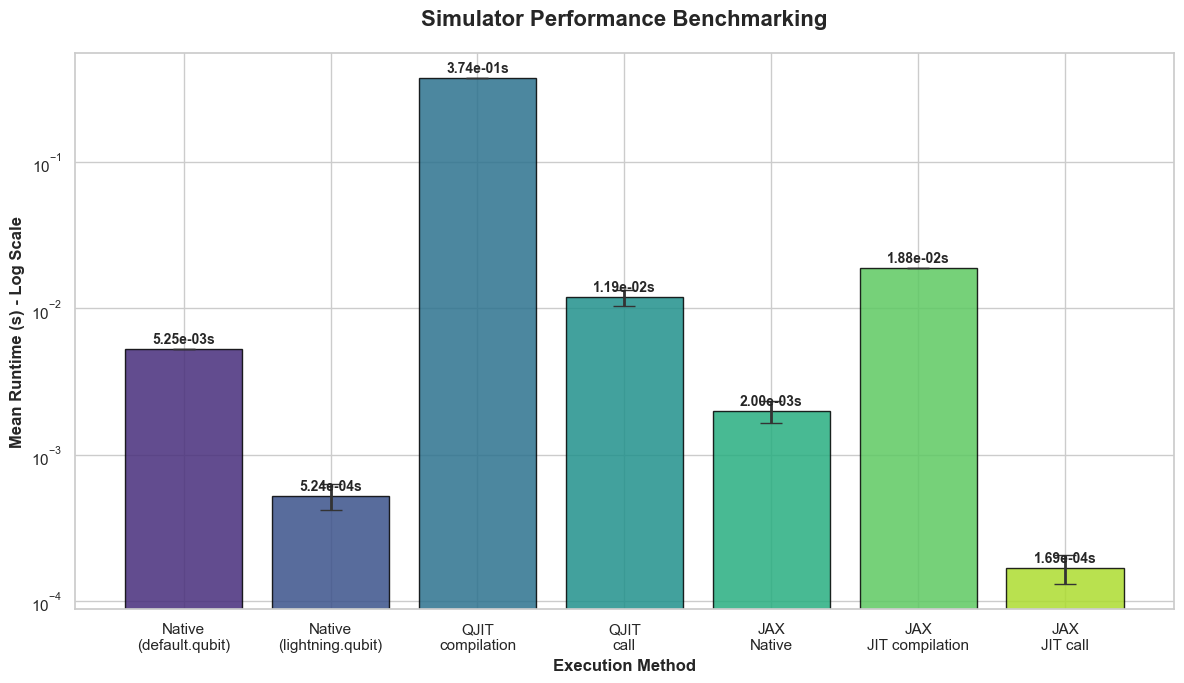

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.family"] = "sans-serif"

# Clean up names for the graph
clean_names = [name.replace(" (", "\n(").replace(" ", "\n", 1) for name in run_names]

# Create the figure
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors (using a nice palette)
colors = sns.color_palette("viridis", len(run_names))

# Plot bars with error bars
bars = ax.bar(
    clean_names, 
    runtimes, 
    yerr=runtimes_err, 
    capsize=8, 
    color=colors, 
    edgecolor="black", 
    alpha=0.85,
    error_kw={'elinewidth': 2, 'ecolor': '#333'}
)

# Use log scale if there's a huge difference (Common in QJIT vs Native)
if max(runtimes) / (min(runtimes) + 1e-9) > 100:
    ax.set_yscale("log")
    ax.set_ylabel("Mean Runtime (s) - Log Scale", fontsize=12, fontweight='bold')
else:
    ax.set_ylabel("Mean Runtime (s)", fontsize=12, fontweight='bold')

# Labels and title
ax.set_title("Simulator Performance Benchmarking", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Execution Method", fontsize=12, fontweight='bold')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height * 1.05,
        f'{height:.2e}s',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.grover import GroverAlgorithm
import pennylane as qml

# 1. Initialize
grover = GroverAlgorithm(num_qubits=2)

# 2. Get a JAX-compatible QNode
qnode = grover.get_qnode(interface="jax")

# 3. Execute
probs = qnode(["00"])

print(probs)


[0.9999999 0.        0.        0.       ]
